In [13]:
import numpy as np

In [14]:
def pre_emphasis(signal, alpha=0.97):
    emphasized = np.zeros_like(signal)
    emphasized[0] = signal[0]
    for i in range(1, len(signal)):
        emphasized[i] = signal[i] - alpha * signal[i - 1]
    return emphasized


In [15]:
def framing(signal, frame_len, frame_step):
    signal_len = len(signal)
    num_frames = int(np.ceil((signal_len - frame_len) / frame_step)) + 1

    pad_len = num_frames * frame_step + frame_len
    padded_signal = np.zeros(pad_len)
    padded_signal[:signal_len] = signal

    frames = np.zeros((num_frames, frame_len))
    for i in range(num_frames):
        start = i * frame_step
        frames[i] = padded_signal[start:start + frame_len]

    return frames


In [16]:
def hamming_window(frame_len):
    window = np.zeros(frame_len)
    for n in range(frame_len):
        window[n] = 0.54 - 0.46 * np.cos(2 * np.pi * n / (frame_len - 1))
    return window


In [17]:
def power_spectrum(frames, nfft):
    num_frames = frames.shape[0]
    spec = np.zeros((num_frames, nfft // 2 + 1))

    for i in range(num_frames):
        fft_frame = np.fft.fft(frames[i], nfft)
        mag = np.abs(fft_frame[:nfft // 2 + 1])
        spec[i] = (1.0 / nfft) * (mag ** 2)

    return spec


In [18]:
def linear_filterbank(n_filters, nfft, fs):
    f_max = fs / 2
    freq_points = np.linspace(0, f_max, n_filters + 2)
    bins = np.floor((nfft + 1) * freq_points / fs).astype(int)

    fbanks = np.zeros((n_filters, nfft // 2 + 1))

    for i in range(1, n_filters + 1):
        left = bins[i - 1]
        center = bins[i]
        right = bins[i + 1]

        for j in range(left, center):
            fbanks[i - 1, j] = (j - left) / (center - left)
        for j in range(center, right):
            fbanks[i - 1, j] = (right - j) / (right - center)

    return fbanks


In [19]:
def log_energy(power_spec, fbanks):
    energy = np.zeros((power_spec.shape[0], fbanks.shape[0]))

    for i in range(power_spec.shape[0]):
        for j in range(fbanks.shape[0]):
            energy[i, j] = np.sum(power_spec[i] * fbanks[j])

    # tránh log(0)
    energy[energy == 0] = np.finfo(float).eps
    return np.log(energy)


In [20]:
def dct_type_2(x, n_ceps):
    N = x.shape[1]
    num_frames = x.shape[0]
    dct_feat = np.zeros((num_frames, n_ceps))

    for i in range(num_frames):
        for k in range(n_ceps):
            sum_val = 0.0
            for n in range(N):
                sum_val += x[i, n] * np.cos(np.pi * k * (2 * n + 1) / (2 * N))
            dct_feat[i, k] = sum_val

    return dct_feat


In [21]:
def lfcc(
    signal,
    fs,
    frame_size=0.025,
    frame_step=0.01,
    nfft=512,
    n_filters=20,
    n_ceps=13
):
    signal = pre_emphasis(signal)

    frame_len = int(frame_size * fs)
    frame_step = int(frame_step * fs)
    frames = framing(signal, frame_len, frame_step)

    window = hamming_window(frame_len)
    frames = frames * window

    power_spec = power_spectrum(frames, nfft)

    fbanks = linear_filterbank(n_filters, nfft, fs)

    log_eng = log_energy(power_spec, fbanks)

    lfcc_feat = dct_type_2(log_eng, n_ceps)

    return lfcc_feat


In [22]:
import librosa
non_speech_mix, sr_1 = librosa.load("C:/Users/Vinh/Documents/Pythonfile/Voice-Activity-Detect/data/test/non_speech_mix.wav")
non_speech, sr_2 = librosa.load("C:/Users/Vinh/Documents/Pythonfile/Voice-Activity-Detect/data/test/non_speech.wav")
speech_mix, sr_3 = librosa.load('C:/Users/Vinh/Documents/Pythonfile/Voice-Activity-Detect/data/test/speech_mix.wav')
speech, sr_4 = librosa.load('C:/Users/Vinh/Documents/Pythonfile/Voice-Activity-Detect/data/test/speech.wav')
sr = sr_1

In [23]:

n_sp_m_feature = lfcc(non_speech_mix[3 * sr:sr * 4], sr_1)
n_sp_feature = lfcc(non_speech[:sr * 1], sr_2)
sp_m_feature = lfcc(speech_mix[sr * 1:sr * 2], sr_3)
sp_feature = lfcc(speech[:sr * 1], sr_4)
print(n_sp_m_feature.shape)

(99, 13)


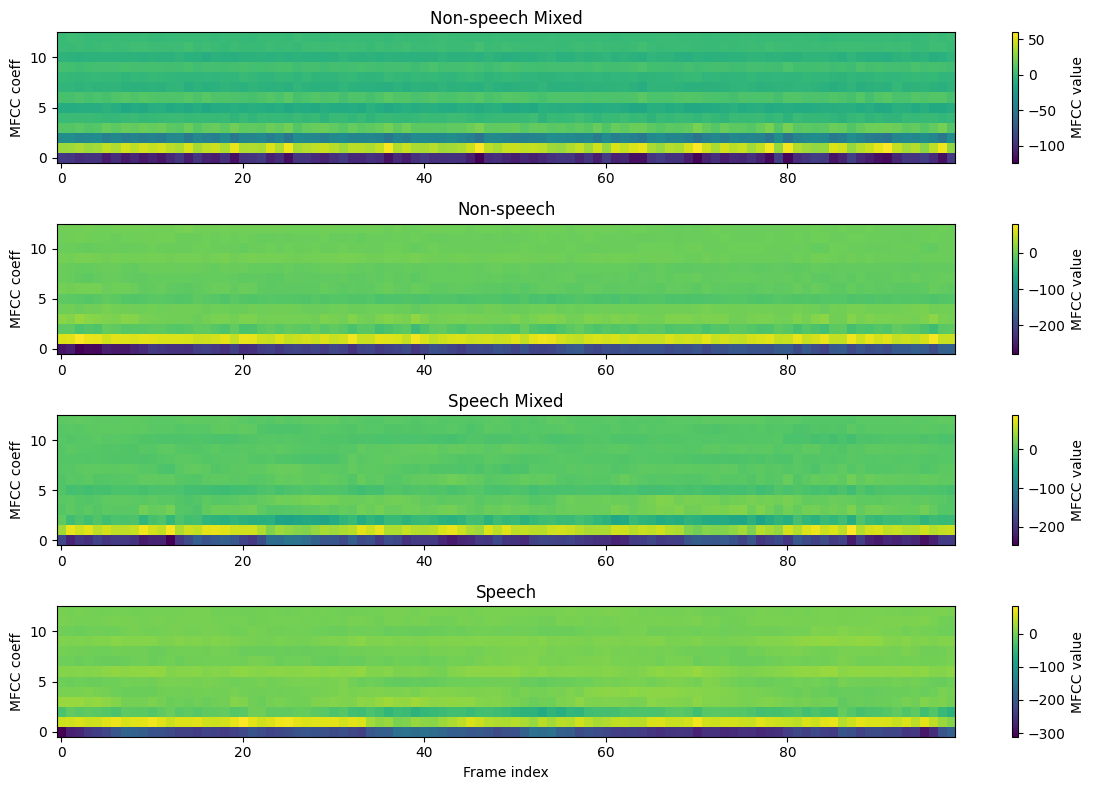

In [24]:
import matplotlib.pyplot as plt

mfcc_list = [n_sp_m_feature, n_sp_feature, sp_m_feature, sp_feature]
titles = ['Non-speech Mixed', 'Non-speech', 'Speech Mixed', 'Speech']

plt.figure(figsize=(12, 8))

for i, mfcc in enumerate(mfcc_list):
    plt.subplot(4, 1, i + 1)
    plt.imshow(mfcc.T, aspect='auto', origin='lower')
    plt.colorbar(label='MFCC value')
    plt.ylabel('MFCC coeff')
    plt.title(titles[i])

plt.xlabel('Frame index')
plt.tight_layout()
plt.show()


In [ ]:
from spafe.features.lfcc import lfcc as lfcc_spafe

def lfcc_library(signal, fs,
                 num_ceps=13,
                 num_filters=20,
                 nfft=512):

    lfcc_feat = lfcc_spafe(
        sig=signal,
        fs=fs,
        num_ceps=num_ceps,
        nfilts=num_filters,
        nfft=nfft
    )

    return lfcc_feat

f1 = lfcc(non_speech_mix, 16000)
f2 = lfcc_library(non_speech_mix, 16000)
print(f1, f2)
from numpy.linalg import norm

def cosine_distance(f1, f2):
    return norm(f1-f2)

print(cosine_distance(f1[0], f2[0]))

[[-1.08316489e+02  4.06762604e+01 -3.99216647e+01  1.29047498e+01
  -1.42142760e+00 -1.24432376e+01  9.94713656e+00 -4.15466130e+00
  -1.73152297e+00  4.29701941e+00 -6.28312453e+00  2.01131827e+00
  -2.31758582e-01]
 [-2.54192840e+02 -3.57796969e-02 -3.39334412e-02 -2.88261903e-02
   1.24344979e-14 -7.54292104e-02 -5.49054611e-02 -5.35095720e-02
  -6.60513746e-02  2.25904115e-01 -8.88178420e-15 -6.28972285e-03
   8.34887715e-14]] [[-24.18850394  12.87196367 -12.60715989   4.126262    -0.4747111
   -3.90129349   3.16793858  -1.33403663  -0.49705132   1.28465362
   -2.0025139    0.67229623  -0.11594653]]
93.98001757541351
